# **Day 84: Scaling ML to Big Data**
*Module 12 - Trustworthy ML and MLOps*

A single Sentinel-2 tile is ~120 million pixels x 13 bands; a national, multi-year analysis is terabytes. Data that do not fit in memory, models that train for days, and predictions over whole countries need different techniques. Most of them are simple: **do less work, do it in chunks, do it in parallel, store it efficiently**.

> When data no longer fits in memory, we process it in chunks, run work in parallel, and use efficient file formats. The same ideas let a model built on a sample run over a whole country.
>
> *Example:* A national land-cover map is predicted tile by tile (for example 1,000 tiles of 10 km) rather than loading the whole country at once.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, os, tracemalloc
from pathlib import Path
from joblib import Parallel, delayed
rng = np.random.default_rng(84)
import tempfile
work = Path(tempfile.gettempdir()) / "ml100_bigdata_demo"; work.mkdir(exist_ok=True)   # large scratch files go to the temp folder, not the project

## **1. Measure Before Optimising**

In [2]:
def timeit(fn, *a, repeat=3, **k):
    best = np.inf
    for _ in range(repeat):
        t = time.perf_counter(); fn(*a, **k); best = min(best, time.perf_counter() - t)
    return best
x = rng.random(2_000_000)
print(f"python loop sum : {timeit(lambda: sum(v * v for v in x[:200_000]), repeat=1) * 10:.3f}s (scaled to 2M)")
print(f"numpy vectorised: {timeit(lambda: np.dot(x, x)):.4f}s")
tracemalloc.start(); big = np.ones((5000, 2000)); cur, peak = tracemalloc.get_traced_memory(); tracemalloc.stop()
print(f"a 5000 x 2000 float64 array uses {peak / 1e6:.0f} MB (float32 would use half)")

python loop sum : 0.218s (scaled to 2M)
numpy vectorised: 0.0002s
a 5000 x 2000 float64 array uses 80 MB (float32 would use half)


## **2. Data Types and File Formats**

In [3]:
n = 2_000_000
df = pd.DataFrame({"pixel_id": np.arange(n), "B4": rng.integers(0, 10000, n), "B8": rng.integers(0, 10000, n), "class": rng.choice(["water", "crop", "forest", "urban"], n)})
mem_default = df.memory_usage(deep=True).sum() / 1e6
df_small = df.astype({"pixel_id": "int32", "B4": "uint16", "B8": "uint16", "class": "category"})
print(f"memory: default {mem_default:.0f} MB -> optimised dtypes {df_small.memory_usage(deep=True).sum() / 1e6:.0f} MB")
t = time.perf_counter(); df_small.to_csv(work / "pixels.csv", index=False); t_csv_w = time.perf_counter() - t
t = time.perf_counter(); df_small.to_parquet(work / "pixels.parquet", index=False); t_pq_w = time.perf_counter() - t
t = time.perf_counter(); pd.read_csv(work / "pixels.csv"); t_csv_r = time.perf_counter() - t
t = time.perf_counter(); pd.read_parquet(work / "pixels.parquet", columns=["B4", "B8"]); t_pq_r = time.perf_counter() - t
print(pd.DataFrame({"size MB": [os.path.getsize(work / "pixels.csv") / 1e6, os.path.getsize(work / "pixels.parquet") / 1e6],
                    "write s": [t_csv_w, t_pq_w], "read s": [t_csv_r, t_pq_r]}, index=["CSV", "Parquet (2 columns read)"]).round(2))

memory: default 74 MB -> optimised dtypes 18 MB


                          size MB  write s  read s
CSV                         48.44     1.17    2.25
Parquet (2 columns read)    16.83     0.44    0.06


| Data | Efficient format |
|---|---|
| Tables | **Parquet** (columnar, compressed, typed; read only needed columns) |
| Rasters for analysis | **Cloud-Optimised GeoTIFF (COG)**: tiled, overviews, HTTP range reads |
| Data cubes (time x bands x y x x) | **Zarr** / NetCDF with chunking (Xarray + Dask) |
| Satellite catalogues | **STAC** metadata to find and load only what we need |

## **3. Out-of-Core Processing**
Compute statistics over data larger than memory by streaming chunks. Welford's algorithm updates mean and variance in one pass, numerically stably; histograms merge across chunks.

In [4]:
H, W, C = 4000, 4000, 4                                                    # 16 M pixels x 4 bands (~256 MB as float32)
mm = np.lib.format.open_memmap(work / "big_scene.npy", mode="w+", dtype=np.float32, shape=(C, H, W))
for r0 in range(0, H, 1000):
    mm[:, r0:r0 + 1000] = rng.normal([[[0.05]], [[0.08]], [[0.06]], [[0.30]]], 0.02, (C, 1000, W)).astype(np.float32)
mm.flush(); del mm

class RunningStats:
    def __init__(self, k): self.n = 0; self.mean = np.zeros(k); self.M2 = np.zeros(k)
    def update(self, X):                                                     # Chan et al. parallel/batched Welford update
        nb = len(X); mb = X.mean(0); vb = X.var(0) * nb; delta = mb - self.mean; tot = self.n + nb
        self.mean += delta * nb / tot; self.M2 += vb + delta ** 2 * self.n * nb / tot; self.n = tot
    @property
    def std(self): return np.sqrt(self.M2 / self.n)

img = np.load(work / "big_scene.npy", mmap_mode="r")                      # memory map: nothing loaded yet
rs = RunningStats(C); t0 = time.perf_counter()
for r0 in range(0, H, 500):
    rs.update(np.asarray(img[:, r0:r0 + 500]).reshape(C, -1).T.astype(np.float64))
print(f"streamed {H * W / 1e6:.0f} M pixels in {time.perf_counter() - t0:.1f}s | band means {rs.mean.round(4)} | stds {rs.std.round(4)}")

streamed 16 M pixels in 1.1s | band means [0.05 0.08 0.06 0.3 ] | stds [0.02 0.02 0.02 0.02]


## **4. Incremental Learning with partial_fit**
Some scikit-learn models learn from mini-batches: `SGDClassifier/Regressor`, `MiniBatchKMeans`, `IncrementalPCA`, `MultinomialNB/GaussianNB`, `MLPClassifier`. Train on data streamed from disk without ever loading it all.

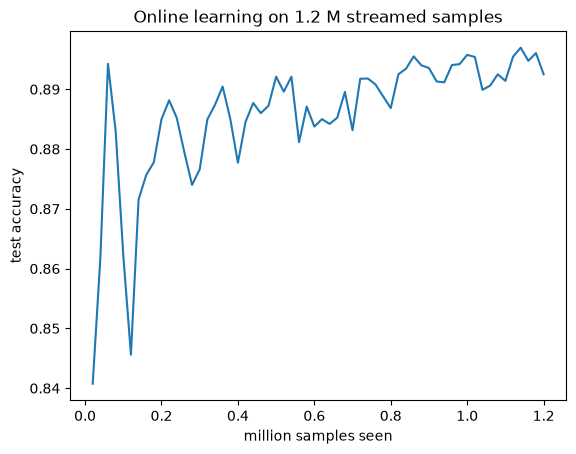

In [5]:
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
def stream_batches(n_batches=60, size=20000, seed=0):
    r = np.random.default_rng(seed); w = np.array([1.5, -2.0, 0.8, 1.2, 0.0, -0.5])
    for _ in range(n_batches):
        Xb = r.normal(size=(size, 6)); yield Xb, (Xb @ w + r.normal(0, 1, size) > 0).astype(int)
scaler, clf = StandardScaler(), SGDClassifier(loss="log_loss", alpha=1e-5, random_state=0)
X_test, y_test = next(stream_batches(1, 20000, seed=999)); accs = []
for i, (Xb, yb) in enumerate(stream_batches()):
    scaler.partial_fit(Xb); clf.partial_fit(scaler.transform(Xb), yb, classes=[0, 1])
    accs.append(clf.score(scaler.transform(X_test), y_test))
plt.plot(np.arange(1, 61) * 20000 / 1e6, accs); plt.xlabel("million samples seen"); plt.ylabel("test accuracy"); plt.title("Online learning on 1.2 M streamed samples"); plt.show()

## **5. Parallelism**
- **Vectorise first** (Day 3): often 100x.
- Many estimators have `n_jobs=-1` (Random Forest, cross-validation, grid search).
- `joblib.Parallel` runs independent jobs (tiles, folds, seeds) on all cores.
- Parallel overhead is real: tiny tasks get slower; memory is multiplied by the number of workers.

In [6]:
from sklearn.ensemble import RandomForestClassifier
Xr, yr = rng.normal(size=(20000, 20)), rng.integers(0, 2, 20000)
for nj in [1, 2, 4, -1]:
    print(f"RandomForest(200 trees) n_jobs={nj:>2}: {timeit(lambda: RandomForestClassifier(200, n_jobs=nj, random_state=0).fit(Xr, yr), repeat=1):.2f}s")

RandomForest(200 trees) n_jobs= 1: 37.07s


RandomForest(200 trees) n_jobs= 2: 18.45s


RandomForest(200 trees) n_jobs= 4: 9.02s


RandomForest(200 trees) n_jobs=-1: 5.57s


In [7]:
def tile_ndvi_stats(r0, c0, size=1000):
    t_ = np.load(work / "big_scene.npy", mmap_mode="r")[:, r0:r0 + size, c0:c0 + size]
    ndvi = (t_[3] - t_[2]) / (t_[3] + t_[2]); return r0, c0, float(ndvi.mean()), float((ndvi > 0.6).mean())
tiles = [(r, c) for r in range(0, H, 1000) for c in range(0, W, 1000)]
t_seq = timeit(lambda: [tile_ndvi_stats(r, c) for r, c in tiles], repeat=1)
t_par = timeit(lambda: Parallel(n_jobs=-1)(delayed(tile_ndvi_stats)(r, c) for r, c in tiles), repeat=1)
print(f"{len(tiles)} tiles: sequential {t_seq:.2f}s | joblib parallel {t_par:.2f}s")

16 tiles: sequential 0.36s | joblib parallel 0.65s


## **6. Smart Sampling: We Rarely Need All Pixels to Train**
Neighbouring pixels are highly correlated, so millions of pixels carry far less information than their count suggests (Day 10, effective sample size). Train on a well-designed **sample** (stratified, spatially spread), then **predict** everywhere in chunks.

In [8]:
from sklearn.ensemble import HistGradientBoostingClassifier
Xbig = rng.normal(size=(1_000_000, 8)); ybig = ((Xbig[:, 0] + np.sin(2 * Xbig[:, 1]) + 0.5 * Xbig[:, 2] * Xbig[:, 3]) > 0).astype(int)
Xv, yv = Xbig[-100_000:], ybig[-100_000:]; rows = []
for n_s in [5_000, 20_000, 100_000, 400_000, 900_000]:
    t = time.perf_counter(); m = HistGradientBoostingClassifier(max_iter=200, random_state=0).fit(Xbig[:n_s], ybig[:n_s])
    rows.append({"training samples": n_s, "fit seconds": time.perf_counter() - t, "validation accuracy": m.score(Xv, yv)})
pd.DataFrame(rows).set_index("training samples").round(4)

,fit seconds,validation accuracy
training samples,,
5000,3.1693,0.9546
20000,3.8231,0.9700
100000,4.9769,0.9794
400000,8.3572,0.9771
900000,14.3514,0.9717


Accuracy saturates long before using all samples, while cost keeps growing linearly. Check the learning curve (Day 42) to decide how much data the model really needs.

## **7. Tools for Bigger Data**

| Tool | Use |
|---|---|
| **Xarray + Dask** | labelled multi-dimensional arrays (time x band x y x x), lazy, chunked, parallel; reads Zarr/COG/NetCDF |
| **Dask-ML** | scalable preprocessing, `Incremental` wrappers, parallel prediction with scikit-learn models |
| **Polars / DuckDB** | very fast tabular processing and SQL on Parquet, out-of-core |
| **Spark (PySpark, Sedona)** | cluster-scale tables and vector data |
| **GPUs (PyTorch, RAPIDS cuML, XGBoost `device="cuda"`)** | deep learning; GPU-accelerated classical ML |
| **Google Earth Engine / Microsoft Planetary Computer / openEO** | server-side processing of planetary-scale archives (Day 87) |

```python
# Lazy, chunked NDVI + parallel model prediction over a Sentinel-2 data cube with Xarray + Dask
import xarray as xr, dask.array as da
cube = xr.open_zarr("s2_cube.zarr")                                   # dims: time, band, y, x; chunked on disk
ndvi = (cube.sel(band="B08") - cube.sel(band="B04")) / (cube.sel(band="B08") + cube.sel(band="B04"))
ndvi_max = ndvi.max("time")                                           # lazy: nothing computed yet
pred = xr.apply_ufunc(lambda b: model.predict(b.reshape(-1, b.shape[-1])).reshape(b.shape[:-1]),
                      features_cube, input_core_dims=[["feature"]], dask="parallelized", output_dtypes=[np.uint8])
pred.rio.to_raster("landcover.tif")                                   # computed chunk by chunk, in parallel
```

# **Part 2: Going Deeper - Approximate Algorithms**

Exact algorithms often have cheaper approximations with tiny accuracy loss:
- **MiniBatchKMeans** instead of KMeans (Day 46)
- **Histogram-based** gradient boosting (binning features; Day 37-38)
- **Random projections** (Johnson-Lindenstrauss) or IncrementalPCA instead of exact PCA
- **Approximate nearest neighbours** (FAISS, HNSW) instead of exact kNN
- **Nystroem / random Fourier features** instead of exact kernel SVMs (Day 32)

In [9]:
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.random_projection import GaussianRandomProjection
Xk = np.vstack([rng.normal(c, 1.0, (100_000, 10)) for c in rng.normal(0, 4, (8, 10))])
for name, m in [("KMeans", KMeans(8, n_init=1, random_state=0)), ("MiniBatchKMeans", MiniBatchKMeans(8, batch_size=4096, n_init=1, random_state=0))]:
    t = time.perf_counter(); m.fit(Xk); print(f"{name:<16} {time.perf_counter() - t:5.2f}s | inertia {m.inertia_ / len(Xk):.3f} per sample")
Xh = rng.normal(size=(2000, 5000))
Z = GaussianRandomProjection(n_components=500, random_state=0).fit_transform(Xh)
i = rng.integers(0, 2000, 500); j = (i + rng.integers(1, 2000, 500)) % 2000   # distinct pairs
d_orig, d_proj = np.linalg.norm(Xh[i] - Xh[j], axis=1), np.linalg.norm(Z[i] - Z[j], axis=1)
print(f"random projection 5000 -> 500 dims: pairwise distances preserved within {np.percentile(np.abs(d_proj / d_orig - 1), 95):.1%} (95th percentile error)")

KMeans            0.91s | inertia 9.996 per sample


MiniBatchKMeans   4.54s | inertia 9.996 per sample


random projection 5000 -> 500 dims: pairwise distances preserved within 5.8% (95th percentile error)


## **Practice Problems**
1. Compute a per-band 2-98% percentile stretch of the big scene **without loading it** (hint: sample random rows from the memory map).
2. Train `MiniBatchKMeans` with `partial_fit` on the big scene's pixels (streamed in blocks) to make an unsupervised 6-class map of the first 1000 rows.
3. Read only the `B8` column from the Parquet file and compute its mean. How long does it take compared with reading the CSV?
4. *(Advanced)* Use `joblib.Parallel` to compute 5-fold CV of 3 different models simultaneously (one job per model) and compare with running them sequentially.

In [10]:
# Solution 1
rows_idx = np.sort(rng.choice(H, 300, replace=False)); sample = np.asarray(img[:, rows_idx, :]).reshape(C, -1)
print("2-98% stretch per band:", np.percentile(sample, [2, 98], axis=1).T.round(4).tolist())
# Solution 2
mbk = MiniBatchKMeans(6, batch_size=8192, random_state=0, n_init=1)
for r0 in range(0, 3000, 500): mbk.partial_fit(np.asarray(img[:, r0:r0 + 500]).reshape(C, -1).T)
labels_first = mbk.predict(np.asarray(img[:, :1000]).reshape(C, -1).T).reshape(1000, W)
print("cluster sizes in first 1000 rows:", np.bincount(labels_first.ravel()))
# Solution 3
t = time.perf_counter(); m_b8 = pd.read_parquet(work / "pixels.parquet", columns=["B8"]).B8.mean(); print(f"Parquet B8 mean {m_b8:.1f} in {time.perf_counter() - t:.3f}s (CSV full read took {t_csv_r:.2f}s)")

2-98% stretch per band: [[0.0089, 0.0911], [0.0389, 0.1211], [0.0189, 0.1011], [0.259, 0.3411]]


cluster sizes in first 1000 rows: [811586 633708 547088 564703 792732 650183]
Parquet B8 mean 4999.6 in 0.025s (CSV full read took 2.25s)


Problem 4 is an **open exercise**. Wrap `cross_val_score(model, X, y, cv=5)` in `delayed(...)` for the three models, run it with `Parallel(n_jobs=3)`, and time it against a plain loop. On Windows, keep `n_jobs` in only one layer (the outer `Parallel` or the model, not both).

In [11]:
# Clean up the large scratch files
import shutil; del img; shutil.rmtree(work, ignore_errors=True); print("scratch files removed")

scratch files removed


## **Key References**
- Rocklin, M. (2015). Dask: Parallel computation with blocked algorithms and task scheduling. *Proceedings of the 14th Python in Science Conference*.
- Hoyer, S., & Hamman, J. (2017). xarray: N-D labeled arrays and datasets in Python. *Journal of Open Research Software*, 5(1), 10.
- Welford, B. P. (1962). Note on a method for calculating corrected sums of squares and products. *Technometrics*, 4(3), 419-420.
- Gorelick, N. et al. (2017). Google Earth Engine: Planetary-scale geospatial analysis for everyone. *Remote Sensing of Environment*, 202, 18-27.
- Zaharia, M. et al. (2016). Apache Spark: A unified engine for big data processing. *Communications of the ACM*, 59(11), 56-65.
- Johnson, J., Douze, M., & Jegou, H. (2021). Billion-scale similarity search with GPUs. *IEEE Transactions on Big Data*, 7(3), 535-547 (FAISS).